## ISSW_Compare_Spectra

Here we're just looking at a couple of spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from importlib import reload  # Python 3.4+
import ISSWlib as IS
import pandas as pd
import os
%matplotlib inline

From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt
UPS_INKStandards//loadings.txt
[ 0.55  0.86  3.02  6.34 11.8  25.4 ]
Reducing number of loadings used from  6  to 5
The shape of chi =  (5, 651)
working on wavelength =  450.0  ...
working on wavelength =  460.0  ...
working on wavelength =  470.0  ...
working on wavelength =  480.0  ...
working on wavelength =  490.0  ...
working on wavelength =  500.0  ...
working on wavelength =  510.0  ...
working on wavelength =  520.0  ...
working on wavelength =  530.0  ...
working on wavelength =  540.0  ...
working on wavelength =  550.0  ...
working on wavelength =  560.0  ...
working on wavelength =  570.0  ...
working on wavelength =  580.0  ...
working on wavelength =  590.0  ...
working on wavelength =  600.0  ...


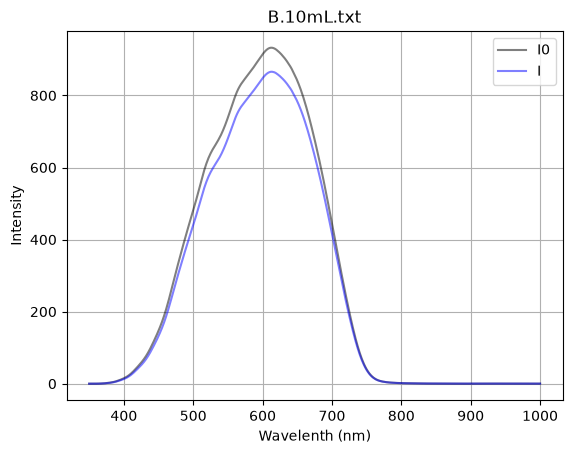

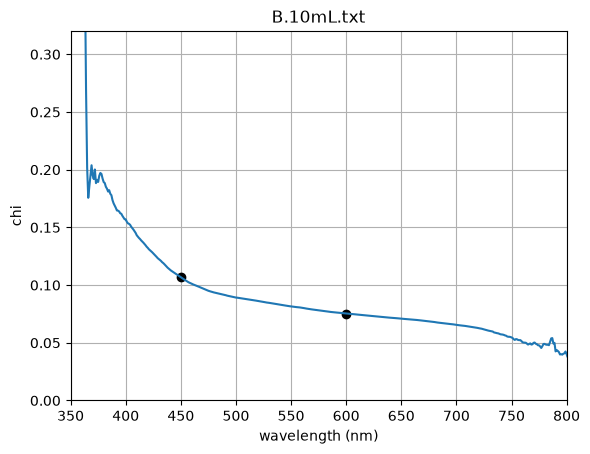

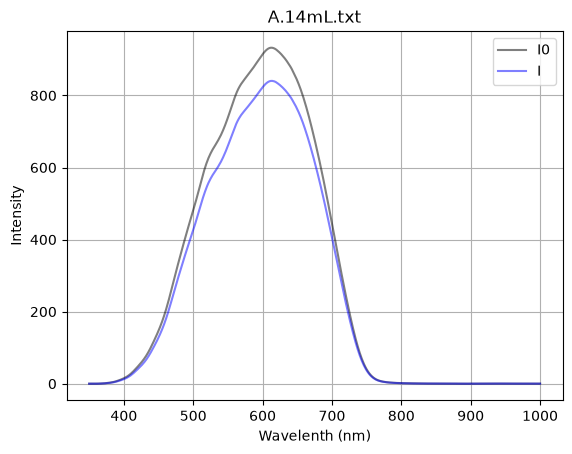

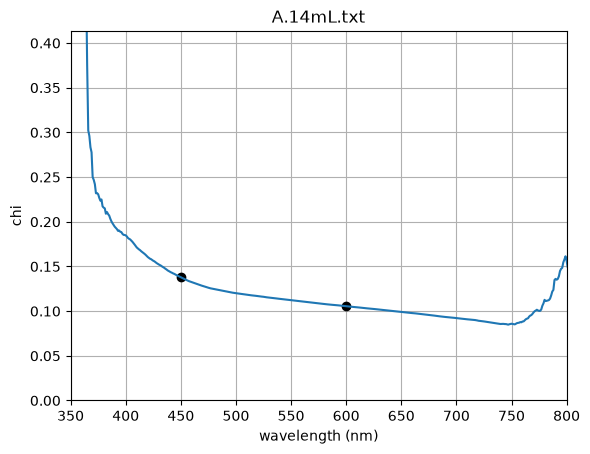

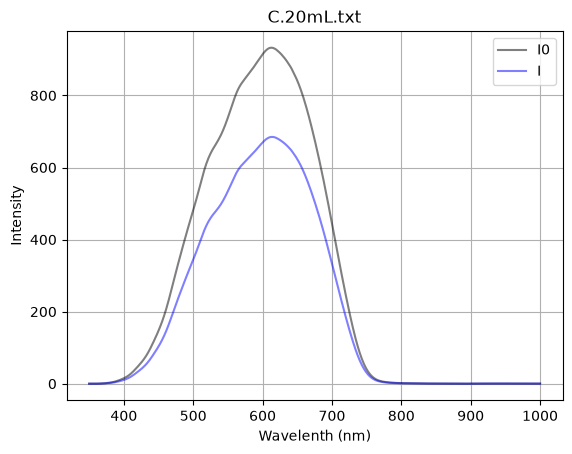

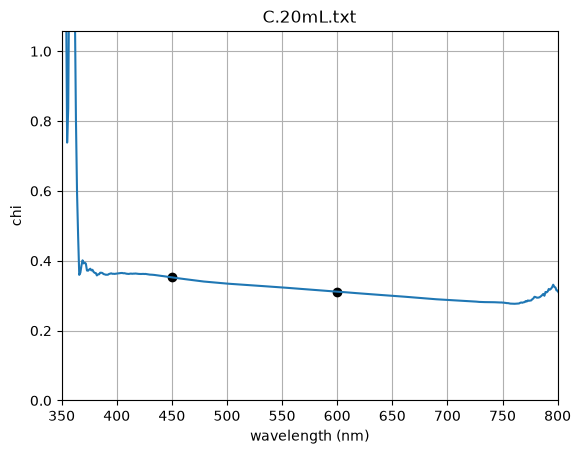

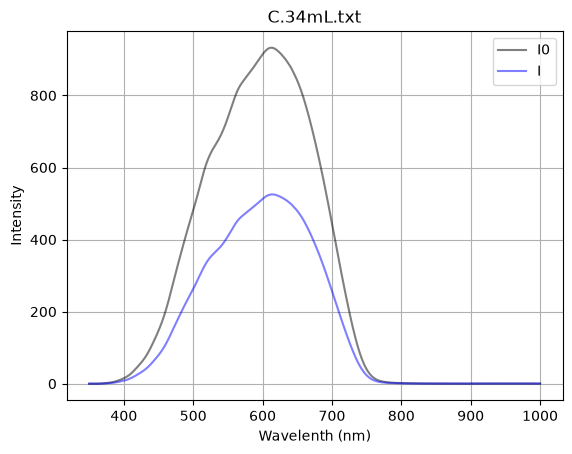

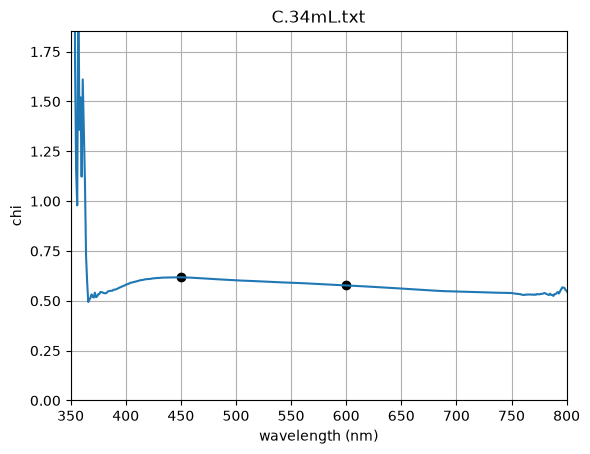

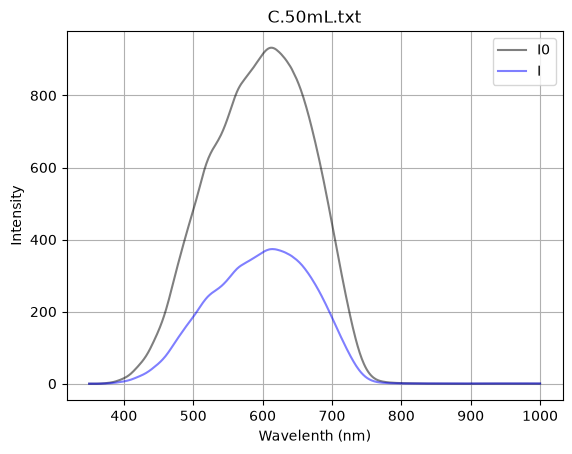

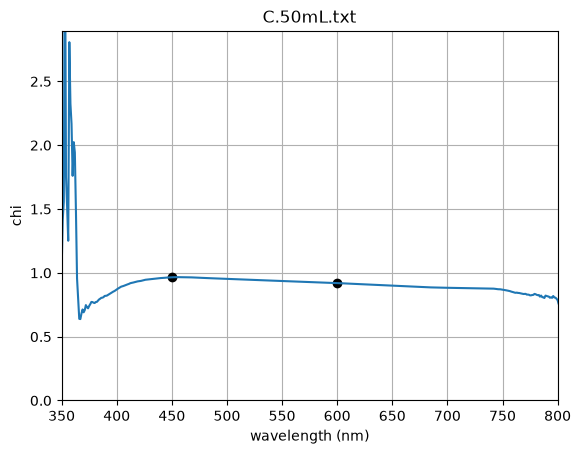

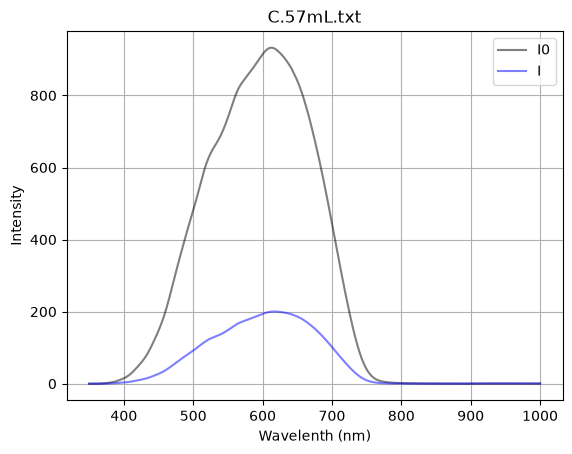

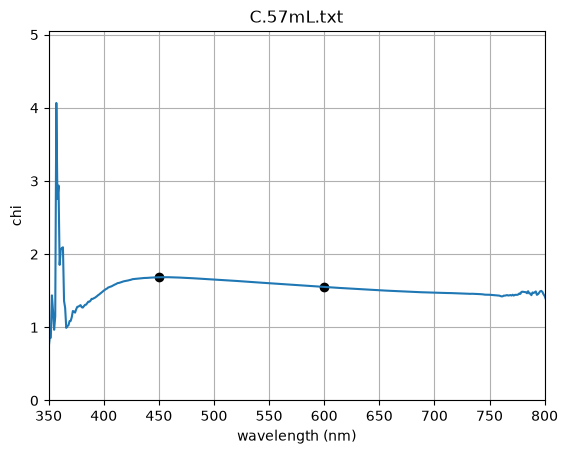

In [2]:
reload(IS)

# Load the ISSW spectra of the standard
spectrum_folder = 'UPS_INKStandards/'; filtertype_std = 'nucleopore'
subset_start = 0 # if 0, we want the start
subset_stop = -2 # if -1, we want all the way to the end
lambda_nm, L_range, chi_range, spectrum_list, number_of_loadings = IS.get_chi_std(spectrum_folder,subset_start,subset_stop)
print('The shape of chi = ', np.shape(chi_range))

# Select the wavelengths we want to focus on
I_lambda_range = np.arange(100,251,10)

# Getting calibration parameters at these wavelengths, and the AAE from those 
p_L_lambda_range = []
betabar_lambda_range = []
for i in range(len(I_lambda_range)):
    k = I_lambda_range[i]
    print('working on wavelength = ', lambda_nm[k], ' ...')
    p_L_lambda, betabar_lambda = IS.get_calibration_parameters(L_range,chi_range[:,k],lambda_nm,k,order=2,plotting=False)
    p_L_lambda_range.append(p_L_lambda)
    betabar_lambda_range.append(betabar_lambda)

In [3]:
# Choose the spectrum folder and load in the list of spectra there
# spectrum_folder = 'Rainier_and_MtCook_comparison/'
# spectrum_folder = 'UPS_Rainier2025-07-03-01/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Adams_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Misc_1/'; filtertype = 'millipore'
# spectrum_folder = 'Ulyana ful/'; filtertype = 'millipore'
# spectrum_folder = 'Ponderosa pine pollen/'; filtertype = 'millipore'
# spectrum_folder = 'Rainier dirt/'; filtertype = 'millipore'

# spectrum_folder = 'UPS_2016Chile/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'
# spectrum_folder = 'UPS_INKStandards/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucInc/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucFul/'; filtertype = 'nucleopore'

which_one = 'assorted'

if which_one == 'UPS_INKStandards':
    spectrum_list = \
    [
        ['UPS_INKStandards/', 0],
        ['UPS_INKStandards/', 1],
        ['UPS_INKStandards/', 2],
        ['UPS_INKStandards/', 3],
        ['UPS_INKStandards/', 4],
        ['UPS_INKStandards/', 5]
    ]
    print('Choosing ', which_one)

elif which_one == 'Ulyana ful':
    spectrum_list = \
    [
        ['Ulyana ful/',   0],
        ['Ulyana ful/',   1],
        ['Ulyana ful/',   2],
        ['Ulyana ful/',   3],
        ['Ulyana ful/',   4]
    ]
    print('Choosing ', which_one)

elif which_one == 'Car exhaust':
    spectrum_list = \
    [
        ['Car exhaust/', 0],
        ['Car exhaust/', 1],
        ['Car exhaust/', 2],
        ['Car exhaust/', 3]
    ]
    print('Choosing ', which_one)

else:
    spectrum_list = \
    [
        ['UPS_Rainier2025-07-03-01/',   0],
        ['UPS_Rainier2025-07-03-01/',   6],
        ['Ponderosa pine pollen/',   2],
        ['Ulyana ful/', 1],
        ['Car exhaust/', 2],
        ['UPS_INKStandards/', 4]
    ]
    print('Choosing ', which_one)

number_of_samples = len(spectrum_list)


Choosing  assorted


['4A.txt', '2A.txt', '3A.txt', '.ipynb_checkpoints', 'Blank.txt', '1B.txt', '6.txt', '1A.txt', '5A.txt', 'spectrum_files.txt']
From getline0list: In  UPS_Rainier2025-07-03-01/spectrum_files.txt , finding these spectra:
      1A.txt
      1B.txt
      2A.txt
      3A.txt
      4A.txt
      5A.txt
      6.txt
extracting UPS_Rainier2025-07-03-01/ 1A.txt
['4A.txt', '2A.txt', '3A.txt', '.ipynb_checkpoints', 'Blank.txt', '1B.txt', '6.txt', '1A.txt', '5A.txt', 'spectrum_files.txt']
From getline0list: In  UPS_Rainier2025-07-03-01/spectrum_files.txt , finding these spectra:
      1A.txt
      1B.txt
      2A.txt
      3A.txt
      4A.txt
      5A.txt
      6.txt
extracting UPS_Rainier2025-07-03-01/ 6.txt
['PP2026-2.txt', 'Blank2.txt', '.ipynb_checkpoints', 'PP2026-1.txt', 'Blank.txt', 'PP2026-3.txt', 'spectrum_files.txt']
From getline0list: In  Ponderosa pine pollen/spectrum_files.txt , finding these spectra:
      PP2026-1.txt
      PP2026-2.txt
      PP2026-3.txt
extracting Ponderosa pine pol

/home/chemistry/LAI_in_snow/ISSW/ISSWlib.py:187: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


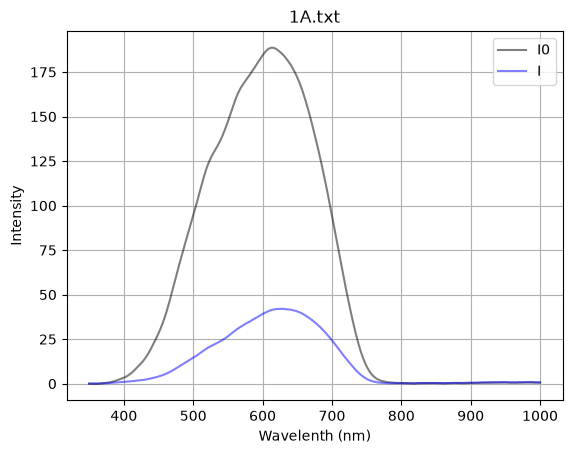

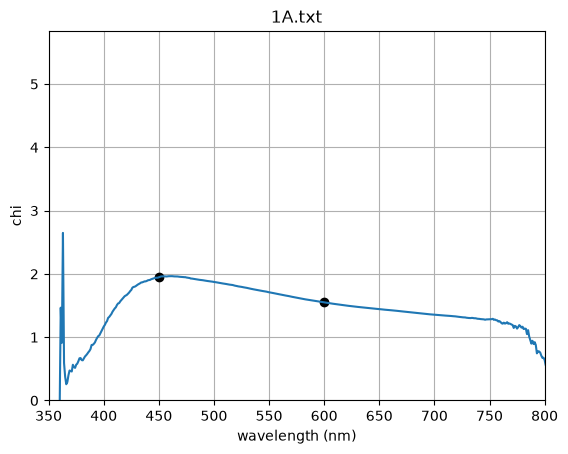

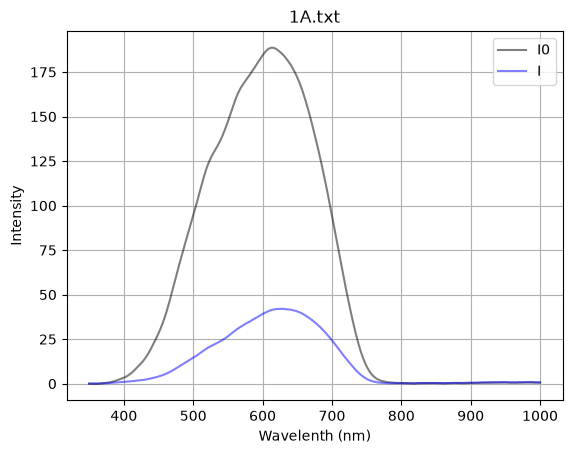

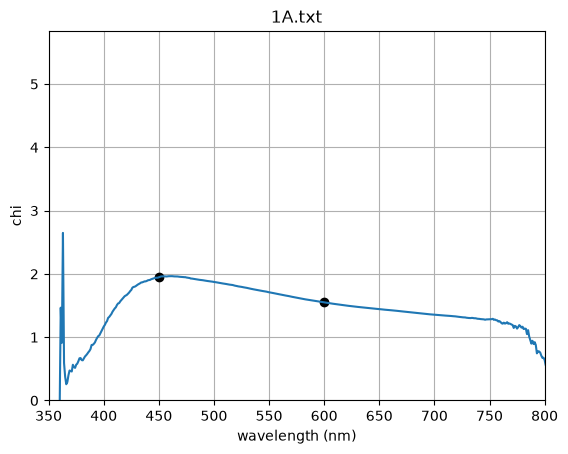

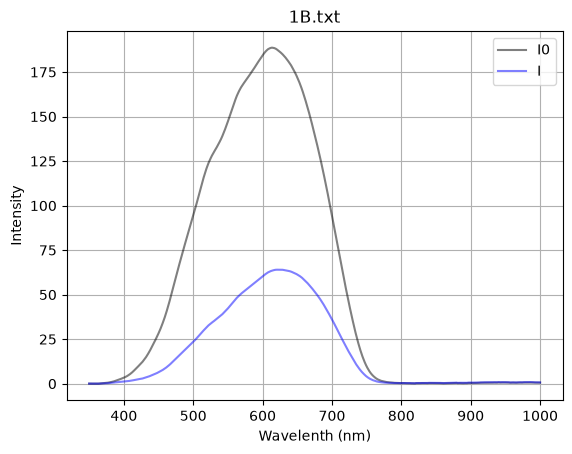

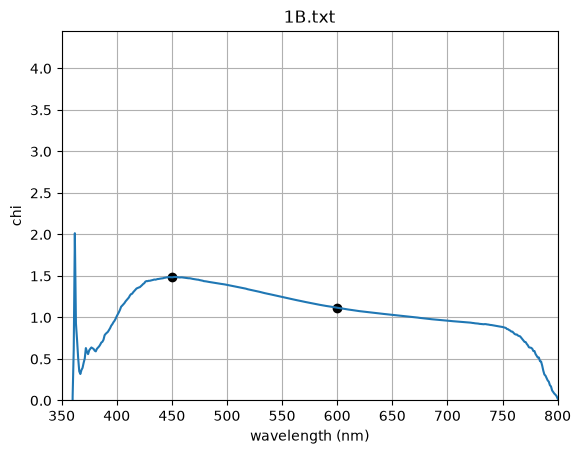

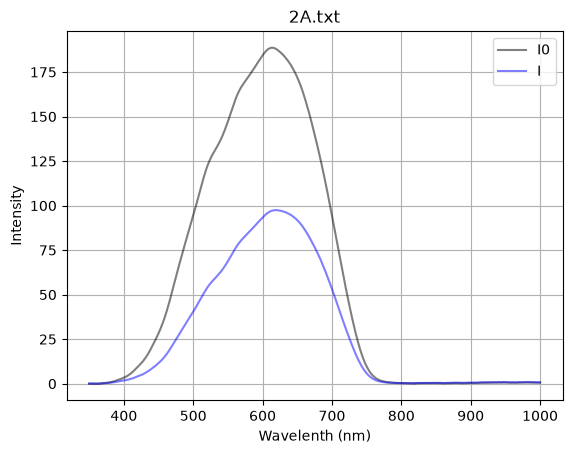

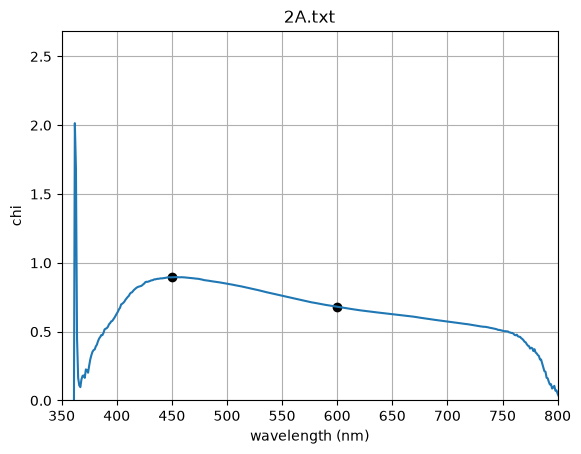

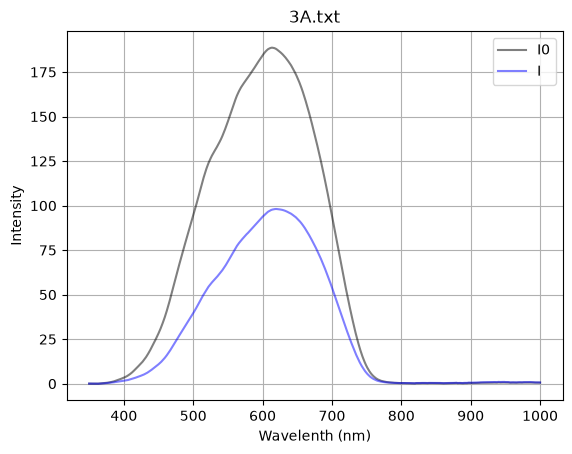

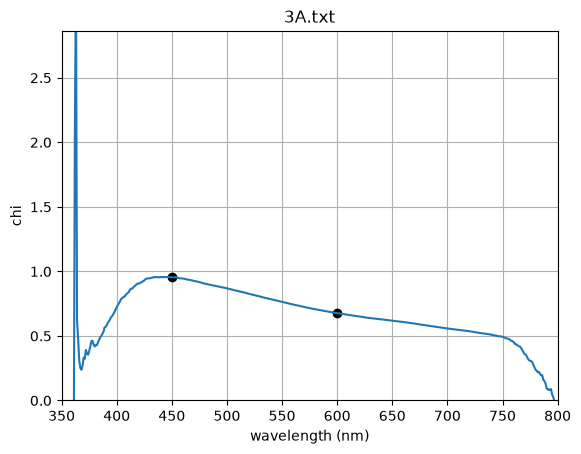

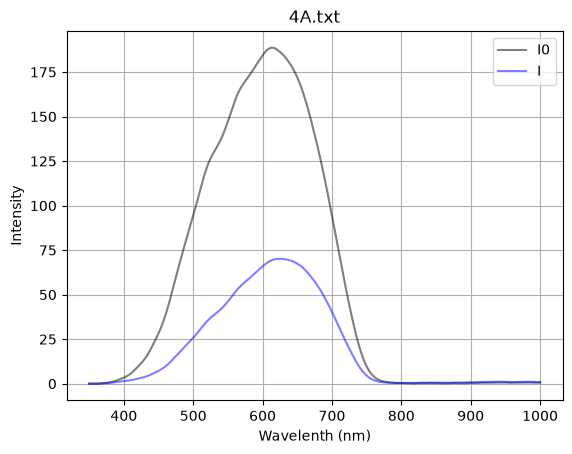

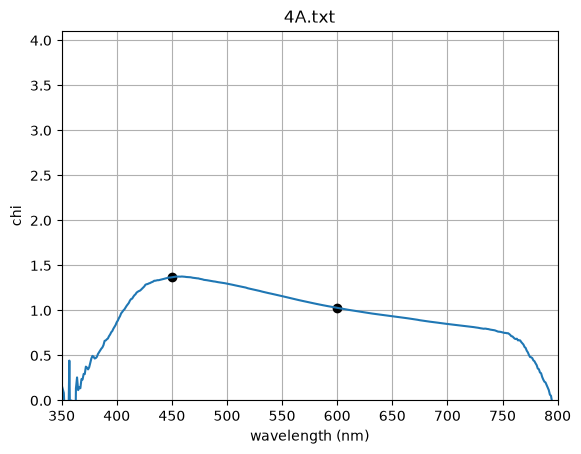

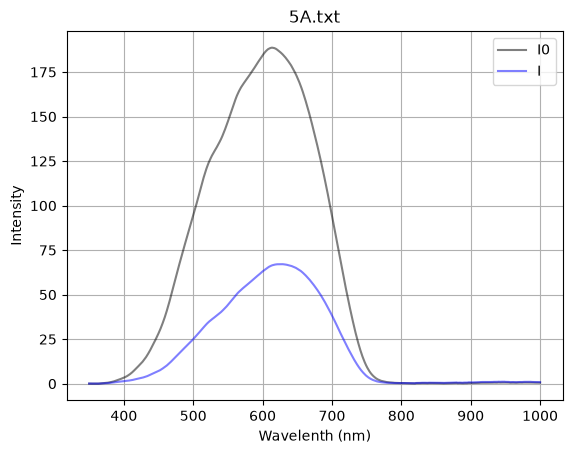

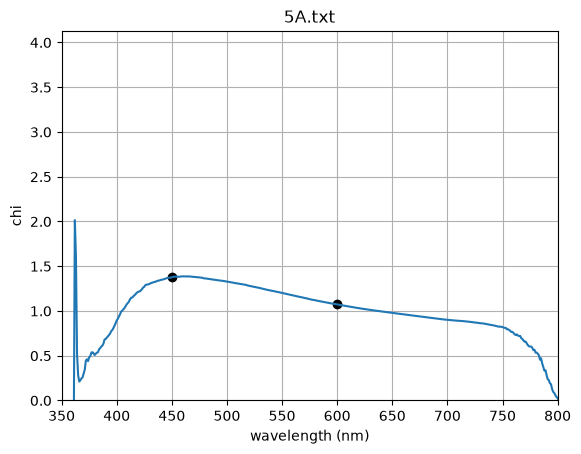

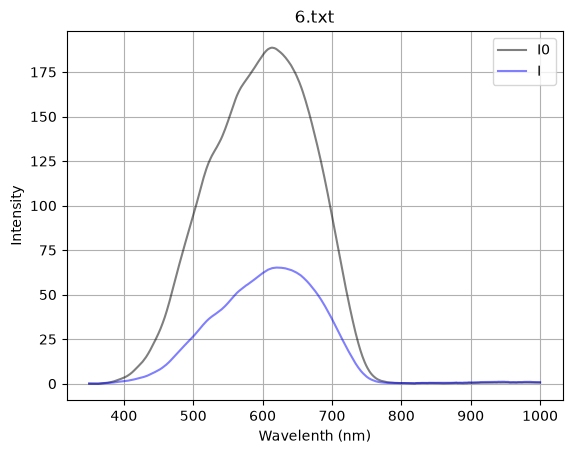

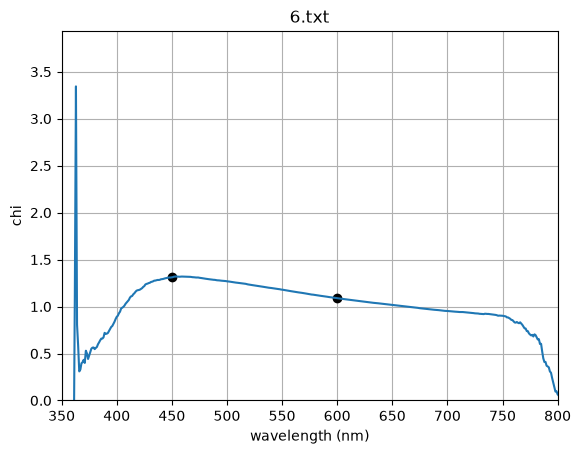

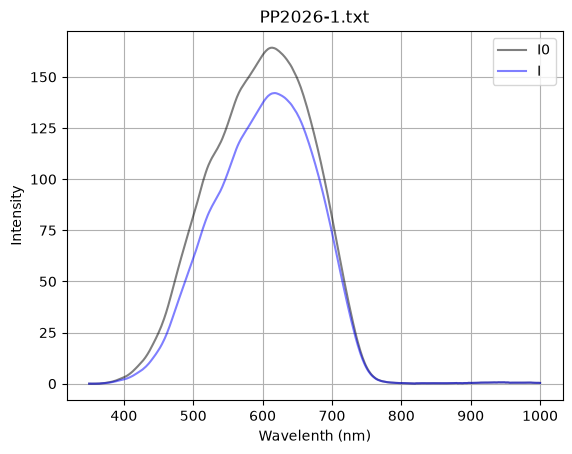

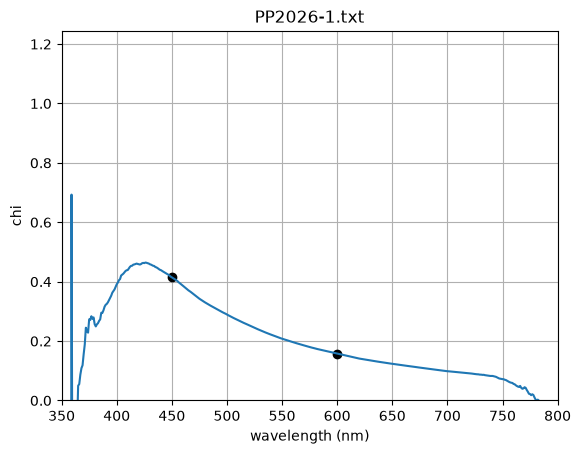

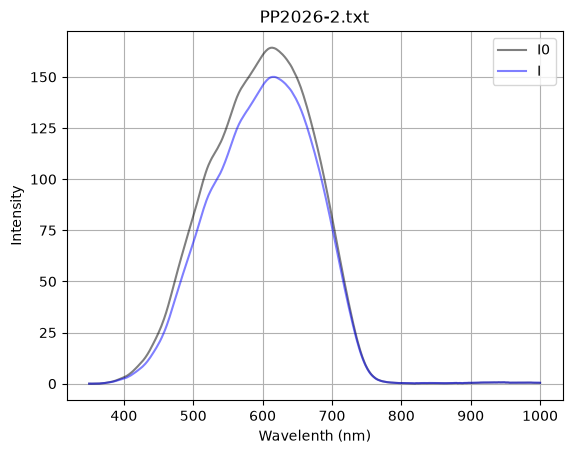

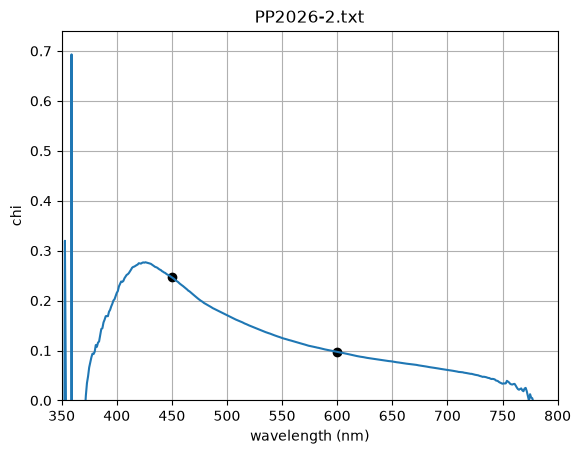

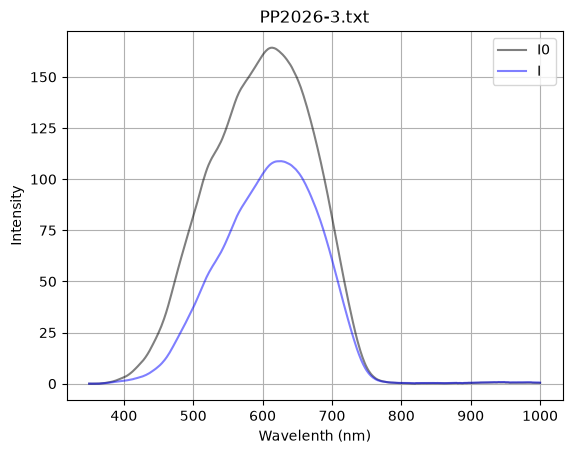

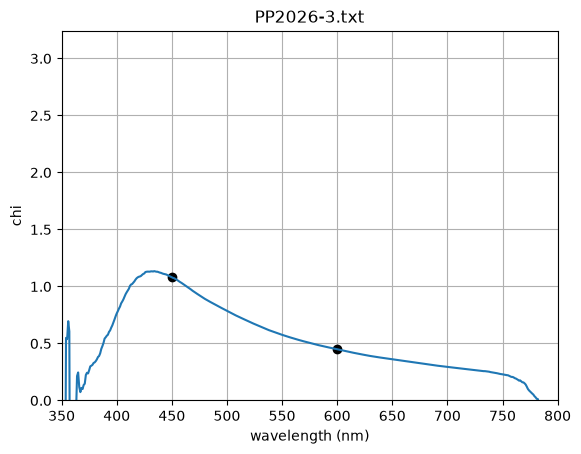

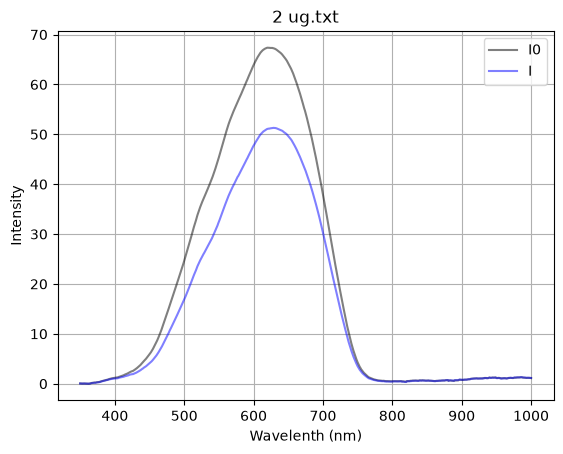

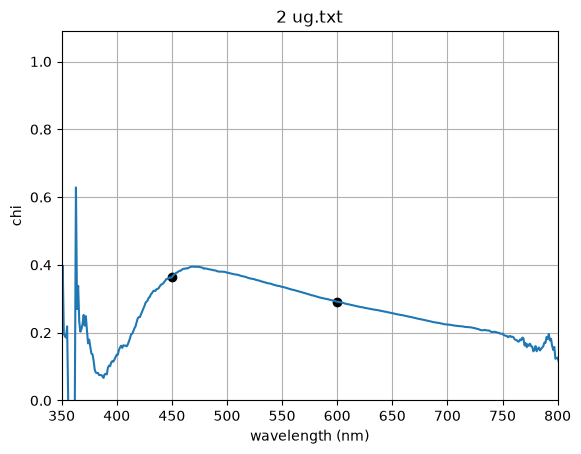

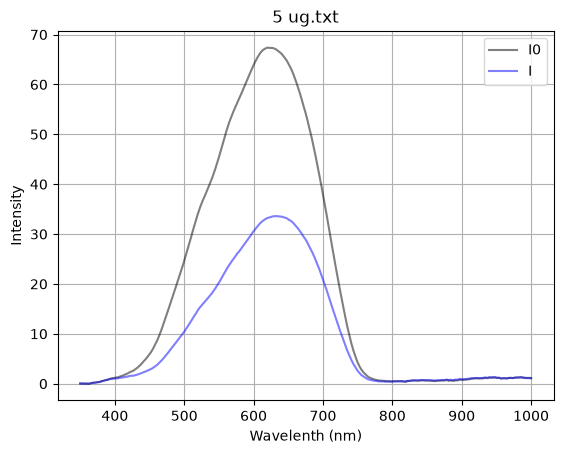

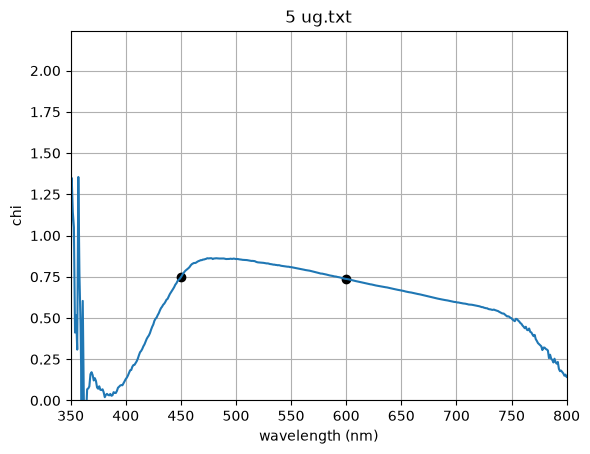

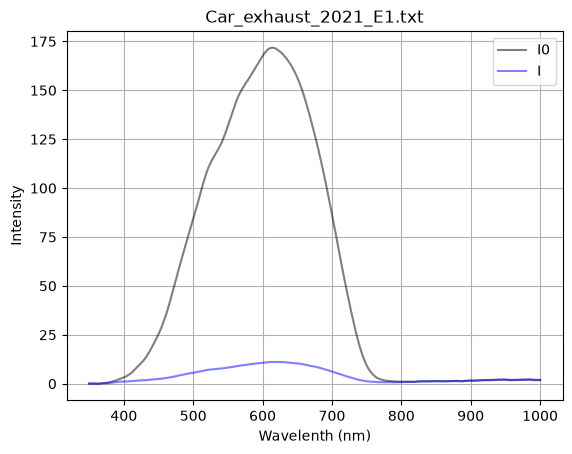

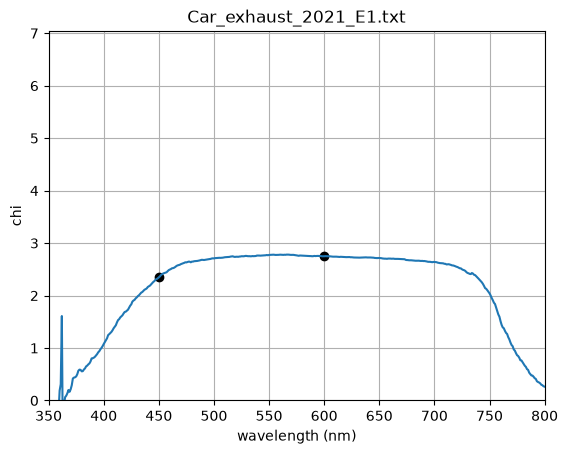

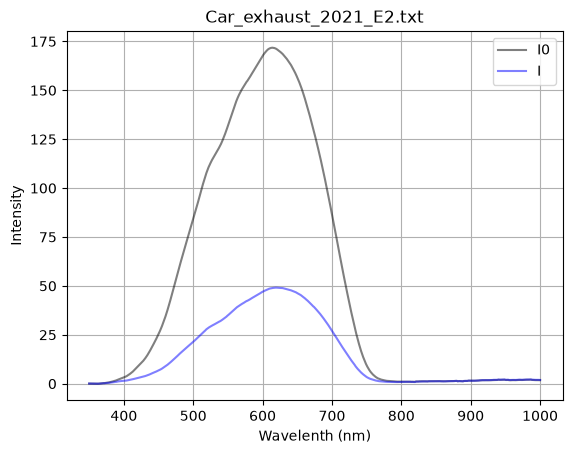

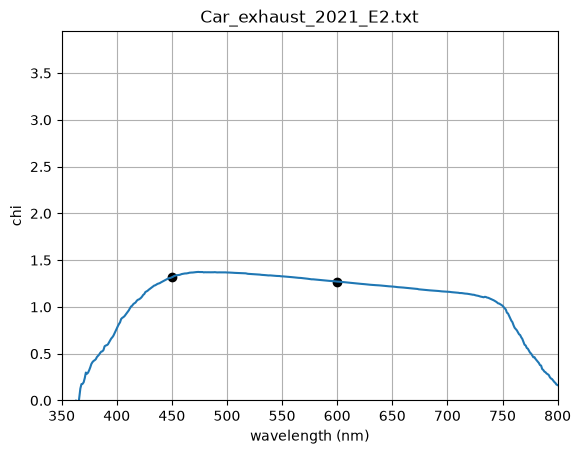

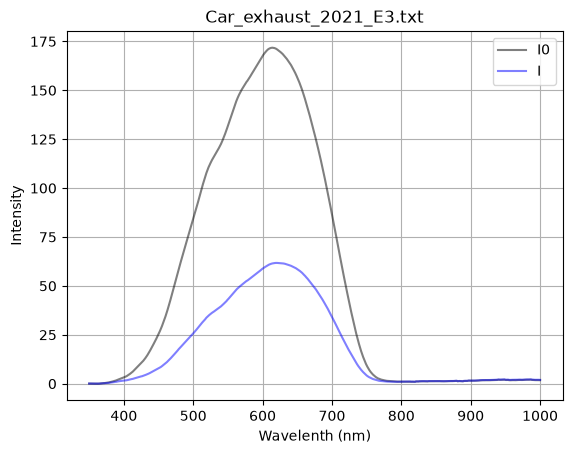

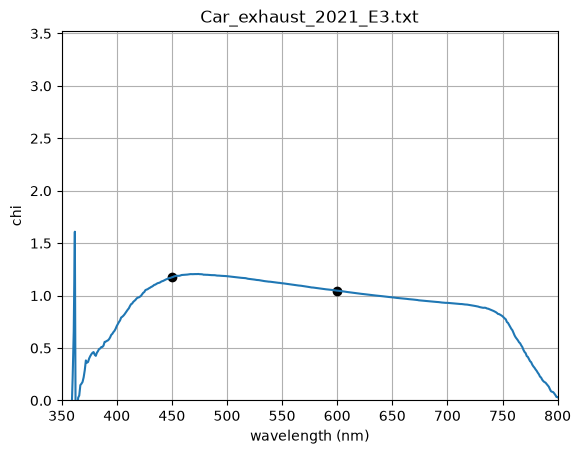

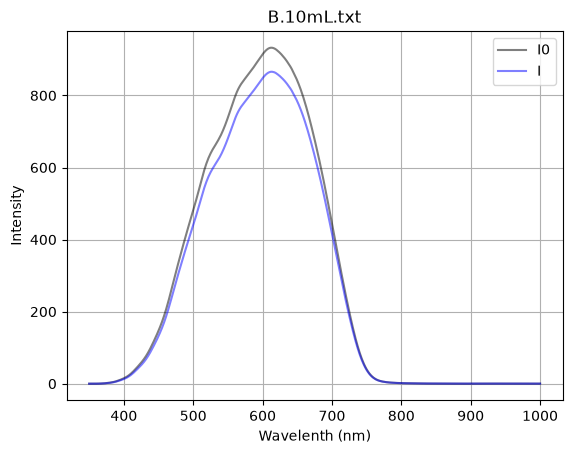

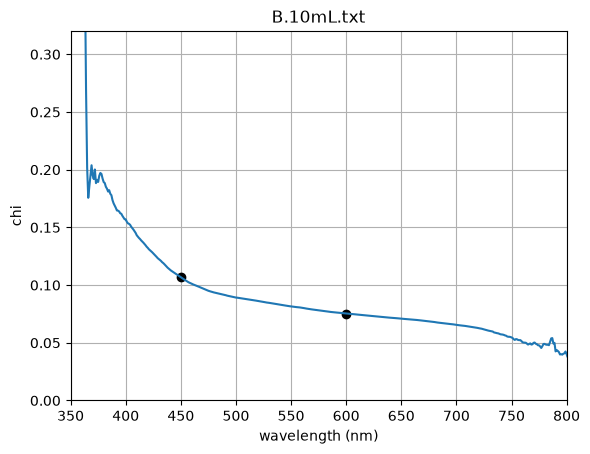

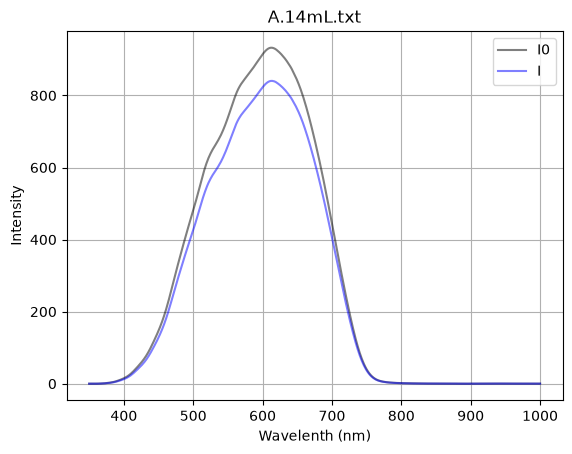

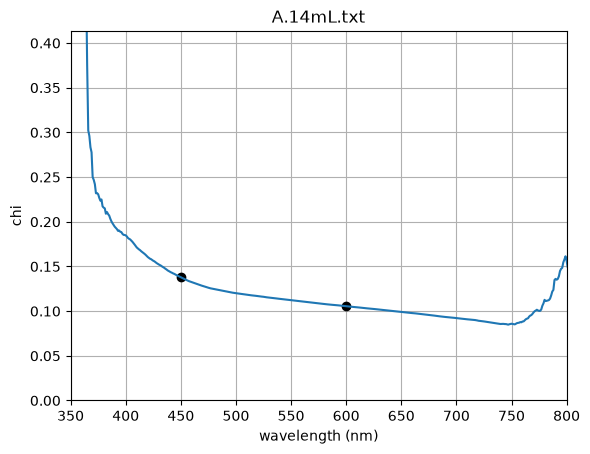

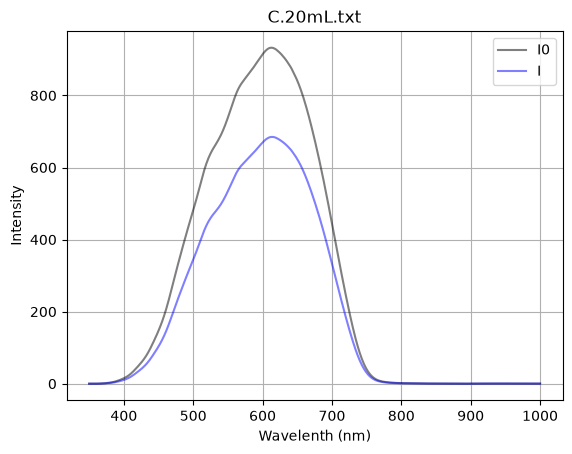

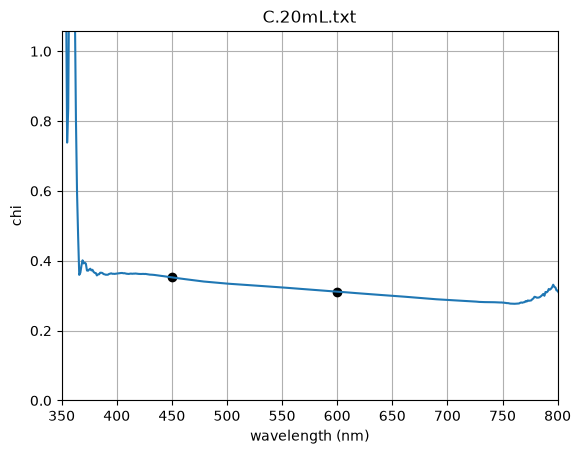

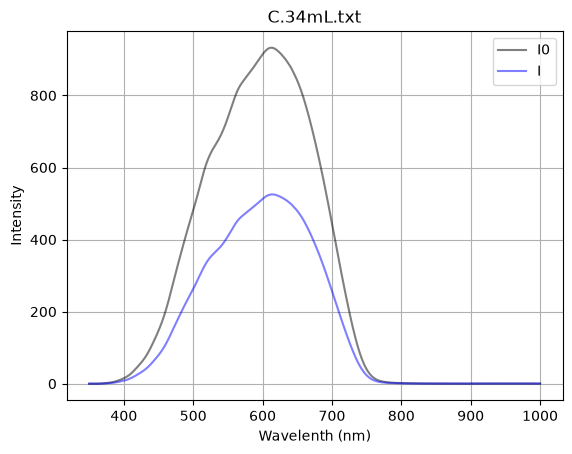

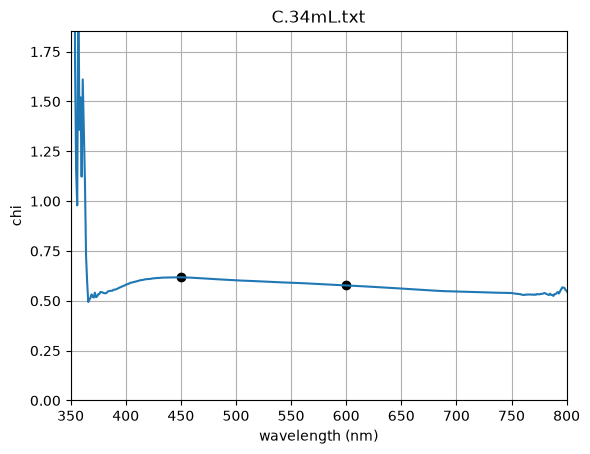

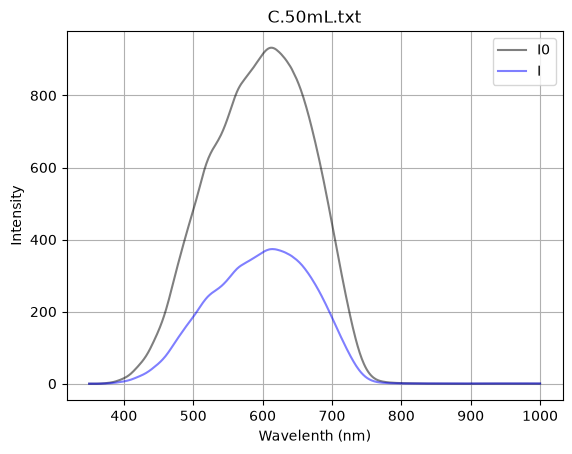

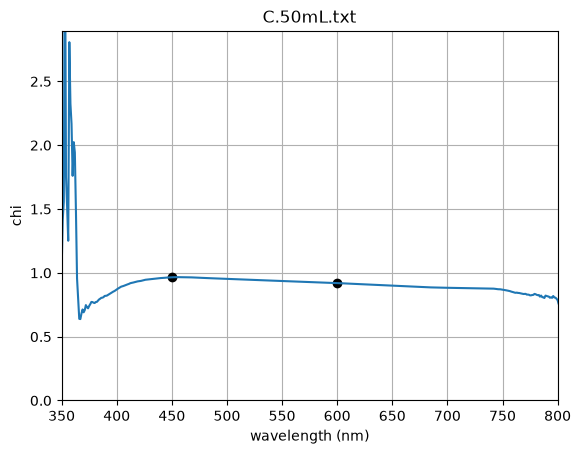

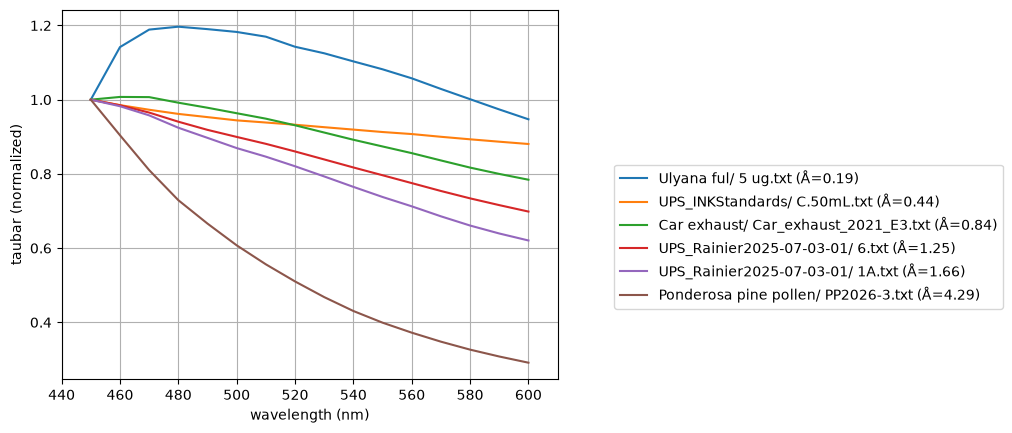

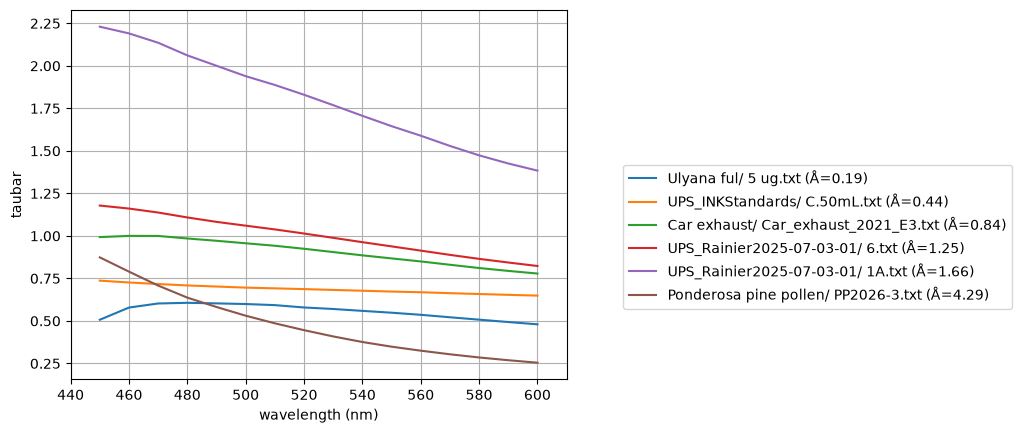

In [4]:
# Extracting the optical depths as a function of wavelength
taubar_list = []
taubar_list_normalized = []
spectrum_name_list = []

for j in range(number_of_samples):
    lambda_nm, chi, spectrum_name = IS.extract_chi_spectrum(spectrum_list[j][0],spectrum_list[j][1],plotting=True)
    taubar = []
    for i in range(len(I_lambda_range)):
        p_L_lambda_std = p_L_lambda_range[i]
        betabar_lambda_std = betabar_lambda_range[i]
        taubar_this_wavelength = betabar_lambda_std*np.polyval(p_L_lambda_std,chi[I_lambda_range[i]])
        taubar.append(taubar_this_wavelength)
    taubar_list.append(taubar)
    taubar_list_normalized.append(taubar/taubar[0])
    spectrum_name_list.append(spectrum_name)
taubar_list = np.array(taubar_list)
taubar_list_normalized = np.array(taubar_list_normalized)

lambda_nm_start = lambda_nm[I_lambda_range[0]]; print('Starting wavelength = ', lambda_nm_start)
lambda_nm_stop = lambda_nm[I_lambda_range[-1]]; print('Ending wavelength = ', lambda_nm_stop)
AAE_list = -np.log(taubar_list[:,0]/taubar_list[:,-1])/np.log(lambda_nm_start/lambda_nm_stop)
AAE_list = np.round(AAE_list,2)

# This will let us put the legend up in order of descending values of the last optical depth of each spectrum
j_in_descending_order = np.argsort(taubar_list_normalized[:,-1],descending=True)
print('j_in_descending_order = ', j_in_descending_order)

# Plot the normalized optical depths (more useful for comparisons)
plt.figure()
for i in range(number_of_samples):
    j = j_in_descending_order[i]
    label = spectrum_name_list[j]+' (Å='+str(AAE_list[j])+')'
    plt.plot(lambda_nm[I_lambda_range],taubar_list_normalized[j,:],label=label)
plt.xlabel('wavelength (nm)')
plt.ylabel('taubar (normalized)')
plt.xlim([lambda_nm[I_lambda_range[0]]-10,lambda_nm[I_lambda_range[-1]]+10])
# plt.ylim([0.6,1.1])
plt.grid(True)
plt.legend(bbox_to_anchor=(1.1, 0.6))

# Plot the unnormalized optical depths (less useful because it depends on loading, unless these are the standards)
plt.figure()
for i in range(number_of_samples):
    j = j_in_descending_order[i]
    label = spectrum_name_list[j]+' (Å='+str(AAE_list[j])+')'
    plt.plot(lambda_nm[I_lambda_range],taubar_list[j,:],label=label)
plt.xlabel('wavelength (nm)')
plt.ylabel('taubar')
plt.xlim([lambda_nm[I_lambda_range[0]]-10,lambda_nm[I_lambda_range[-1]]+10])
# plt.ylim([0.6,1.1])
plt.grid(True)
plt.legend(bbox_to_anchor=(1.1, 0.6))